In [ ]:
%load_ext autoreload
%autoreload 2
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.95'
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pickle as pk
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size': 16})
# increase legend font size
plt.rcParams.update({'legend.fontsize': 14})

from paste_backlight_utils import (
    get_project_paths, build_config, load_halo_catalog,
    generate_maps, make_galaxy_map, compute_ngal_vs_z,
    stack_snapshot_maps,
    check_nz_nbar_consistency, nbar_to_nz_lens,
    update_nz_from_mock_catalog,
    measure_hod_from_catalog,
    compute_shot_noise_Cl, compute_Cl_ratio_in_bands,
    compare_sim_vs_theory_hmf,
    compute_Cl_gg_1h_2h, compute_hod_shot_noise_Cl,
    print_diagnostic_summary,
)
import h5py as h5
def load_halo_catalog(filepath):
    """Load halo catalog from HDF5 and return (ra, dec, z, M200c, vlos)."""
    with h5.File(filepath, 'r') as f:
        RA = f['RA'][:]
        DEC = f['DEC'][:]
        Z = f['REDSHIFT'][:]
        M200c = f['M200'][:]
        vlos = np.zeros_like(Z)  # Placeholder since vlos is not in the file
    return RA, DEC, Z, M200c, vlos


paths = get_project_paths()

from get_sim_maps import setup_sim_map
from scipy import interpolate


1 1


In [1]:
nside_map = 512
# Build all config dicts (nbar and nz_lens derived from single canonical source)
gal_zmin = 0.4
gal_zmax = 0.7
nbar_comoving = 1e-4
(sim_params_dict, halo_params_dict, analysis_dict,
 other_params_dict, cosmo_jax, zarray_lens, nz_lens, gal_zrange) = build_config(
    paths["params"], paths["data"], nbar_comoving=nbar_comoving, gal_zmin=gal_zmin, gal_zmax=gal_zmax)

gal_zmin, gal_zmax = gal_zrange
print(f"Galaxy z-range: [{gal_zmin}, {gal_zmax}]")



[nz consistency] max fractional mismatch = 0.0000e+00, mean = 0.0000e+00  (rtol=0.05)
Galaxy z-range: [0.4, 0.7]


In [2]:
# Initialize model pipeline
from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
M_halo_MIN = 10**13.0
halo_selM_mask = jnp.where(profiles_test.M_array > M_halo_MIN, 1.0, 0.0)
halo_selM_mask_2d = jnp.tile(halo_selM_mask, (halo_params_dict['nz'], 1))

# halo_selz_mask = jnp.where((profiles_test.z_array > gal_zmin) & (profiles_test.z_array < gal_zmax), 1.0, 0.00001)
# halo_selz_mask_2d = jnp.tile(halo_selz_mask[:, None], (1, halo_params_dict['nM']))
# halo_sel_mask_2d = halo_selM_mask_2d * halo_selz_mask_2d

halo_sel_mask_2d = halo_selM_mask_2d

profiles_test.Ncen_mat = profiles_test.Ncen_mat * halo_sel_mask_2d
profiles_test.Nsat_mat = profiles_test.Nsat_mat * halo_sel_mask_2d
# profiles_test.hmf_Mz_mat = profiles_test.hmf_Mz_mat * halo_sel_mask_2d

Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)




In [1]:
# plt.figure()
# plt.plot(Pkz_test.kPk_array, Pkz_test.Pmm_sup_tot_mat[:,0], label="Pmm_sup_tot_mat")
# plt.ylim(0.2,1.8)
# plt.xlabel("k")
# plt.grid()
# plt.xscale("log")
# plt.ylabel("P(k)")
# plt.legend()
# plt.show()




In [2]:
# # Plot model C_ell^{gy}, C_ell^{g tau}, C_ell^{gg}
# fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# axes[0].plot(Cls_test.ell_array, Cls_test.Cl_gal_y_tot_mat[:, 0], color="blue")
# axes[0].set(xscale="log", yscale="log", xlabel=r"$\ell$", ylabel=r"$C_\ell^{\mathrm{gy}}$", xlim=(100, 2e3))

# axes[1].plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:, 0, 0], color="blue")
# axes[1].set(xscale="log", yscale="log", xlabel=r"$\ell$", ylabel=r"$C_\ell^{\mathrm{gg}}$", xlim=(100, 2e3), ylim=(1e-6, 1e-2))
# axes[1].grid()
# # axes[2].plot(Cls_test.ell_array, Cls_test.Cl_gal_tau_tot_mat[:, 0], color="blue")
# # axes[2].set(xscale="log", yscale="log", xlabel=r"$\ell$", ylabel=r"$C_\ell^{\mathrm{g\tau}}$", xlim=(100, 3e3))

# # plt.tight_layout()




In [3]:
# Setup simulated map generation
nside = 512
PROFILE_TIMING = True

halo_params_dict_copy = halo_params_dict.copy()

halo_params_dict_copy.update({
    'rmin': 0.005, 'rmax': 10.0, 'nr': 48,
    'zmin': 0.005, 'zmax': 0.8, 'nz': 52,
    'lg10_Mmin': 12.0, 'lg10_Mmax': 15.75, 'nM': 42,
})

mock_params_dict_setup = {
    "nside": nside,
    "get_ymap": True, "get_kSZmap": True, "get_taumap": True,
    "get_kappamap": True, "get_galmap": True, "smooth_profiles": True,
}
Prof_test = setup_sim_map(
    sim_params_dict, halo_params_dict_copy, analysis_dict,
    other_params_dict, mock_params_dict_setup, Profiles_obj=profiles_test)


    

In [4]:
# Load halo catalog and generate maps
sdir = f"{paths['data']}/manticore"
save_map_fname = f"{sdir}/allmaps_sim_B12_nside{nside}_split0of1_paste_testlowmass.pkl"

ra_all, dec_all, z_all, M200c_all, vlos_all = load_halo_catalog(
    f"{sdir}/manticore_deep_mcmc12_z0_clusters.hdf5")
    # f"{sdir}/halo_catalog_Mlim_1e14_zlim_0.4.h5")
    # f"{sdir}/halo_catalog_Mlim_1e13_zlim_0.4.h5")

print(len(ra_all))
print(f"RA range before adjustment: [{ra_all.min()}, {ra_all.max()}]")

indsel = np.where((ra_all > 2e-5) & (ra_all < 360-2e-5) & (dec_all > -90+2e-5) & (dec_all < 90-2e-5))
ra_all = ra_all[indsel]
dec_all = dec_all[indsel]
z_all = z_all[indsel]
M200c_all = M200c_all[indsel]
vlos_all = vlos_all[indsel]

print(f"RA range after clipping: [{ra_all.min()}, {ra_all.max()}]")

print(len(ra_all))

print(f"Number of halos: {len(M200c_all)}")
print(f"log10(M200c) — min: {np.log10(M200c_all).min():.2f}, mean: {np.log10(M200c_all).mean():.2f}, max: {np.log10(M200c_all).max():.2f}")
print(f"Mean z: {z_all.mean():.2f}")




11070358
RA range before adjustment: [3.285544059713503e-05, 359.9999967107072]
RA range after clipping: [3.285544059713503e-05, 359.9999592988179]
11070356
Number of halos: 11070356
log10(M200c) — min: 13.00, mean: 13.39, max: 15.70
Mean z: 0.50


In [7]:
saved_data = generate_maps(
    ra_all, dec_all, z_all, M200c_all, vlos_all,
    Prof_test, mock_params_dict_setup, nside,
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict,
    save_path=save_map_fname, profile_timing=PROFILE_TIMING)




Processing halo batch 1/1...
[PROFILE] Chunk 1/1 - Pixel finding: 106.26s

--- JAX Map Generation Timing Profile ---
setup_common                       : 5.8821 seconds
setup_tau_interpolator             : 0.3421 seconds
ymap_generation_and_assembly       : 59.4715 seconds
ksz_map_generation_and_assembly    : 59.2290 seconds
tau_map_generation_and_assembly    : 58.6622 seconds
kappa_map_generation_and_assembly  : 58.7284 seconds
galaxy_ppf_interpolator_creation   : 0.2204 seconds
galaxy_population                  : 6.1227 seconds
galaxy_catalog_filtering           : 0.6834 seconds
total_execution                    : 249.3633 seconds
---------------------------------------

Chunk 1/1: galaxy catalog shape = (2763941, 6)
[PROFILE] Chunk 1/1 - JAX map gen: 249.41s
Saved maps to /mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/manticore/allmaps_sim_B12_nside512_split0of1_paste_testlowmass.pkl


In [8]:
# plt.figure()
# _ = plt.hist(ra_all, bins=50)
# plt.xlabel("Right Ascension")
# plt.ylabel("Frequency")
# plt.title("Distribution of Halo Right Ascensions")
# plt.show()


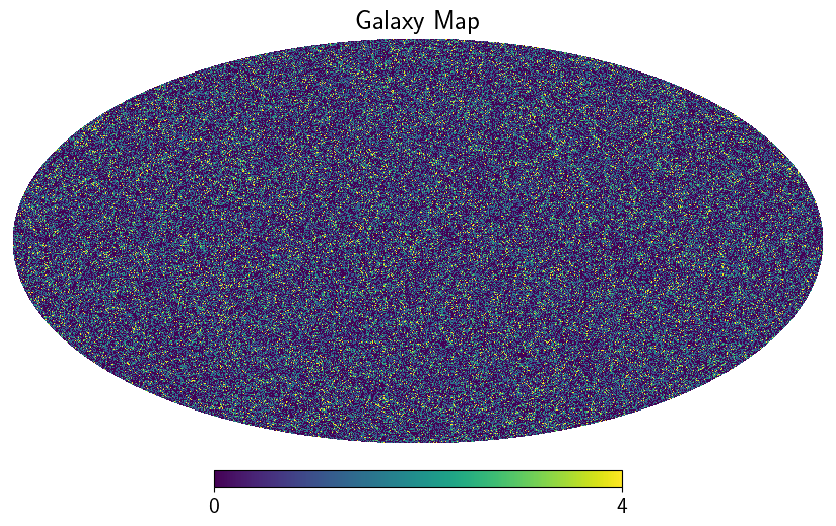

In [10]:
# Load saved data and build galaxy map (using canonical gal_zrange)
saved_data = pk.load(open(save_map_fname, "rb"))
mock_gals = np.array(saved_data["mock_gals_all"][0])
mock_gals[:,0] = np.clip(np.mod(mock_gals[:,0], 360.0), 0.0, 360.0 - 2e-5)
mock_gals[:,1] = np.clip(np.mod(mock_gals[:,1] + 90.0, 180.0) - 90.0, -90.0, 90.0)

map_gal = make_galaxy_map(mock_gals, nside, zmin=gal_zmin, zmax=gal_zmax)

# hp.mollview(np.log10(map_gal + 1e-10), title="Galaxy Map")
hp.mollview(map_gal, title="Galaxy Map", min=0, max=np.percentile(map_gal, 97))




[Shot noise] N_gal = 2758532, nbar = 219517.0 /sr, Cl_shot = 4.5555e-06
[HOD shot noise] Cl_shot (theory integral) = 8.0361e-06
[Cl ratio diagnostics]
  ell [ 100,  300]: <Cl_meas/Cl_th> = 1.199
  ell [ 300,  700]: <Cl_meas/Cl_th> = 1.449
  ell [ 700, 1200]: <Cl_meas/Cl_th> = 1.314


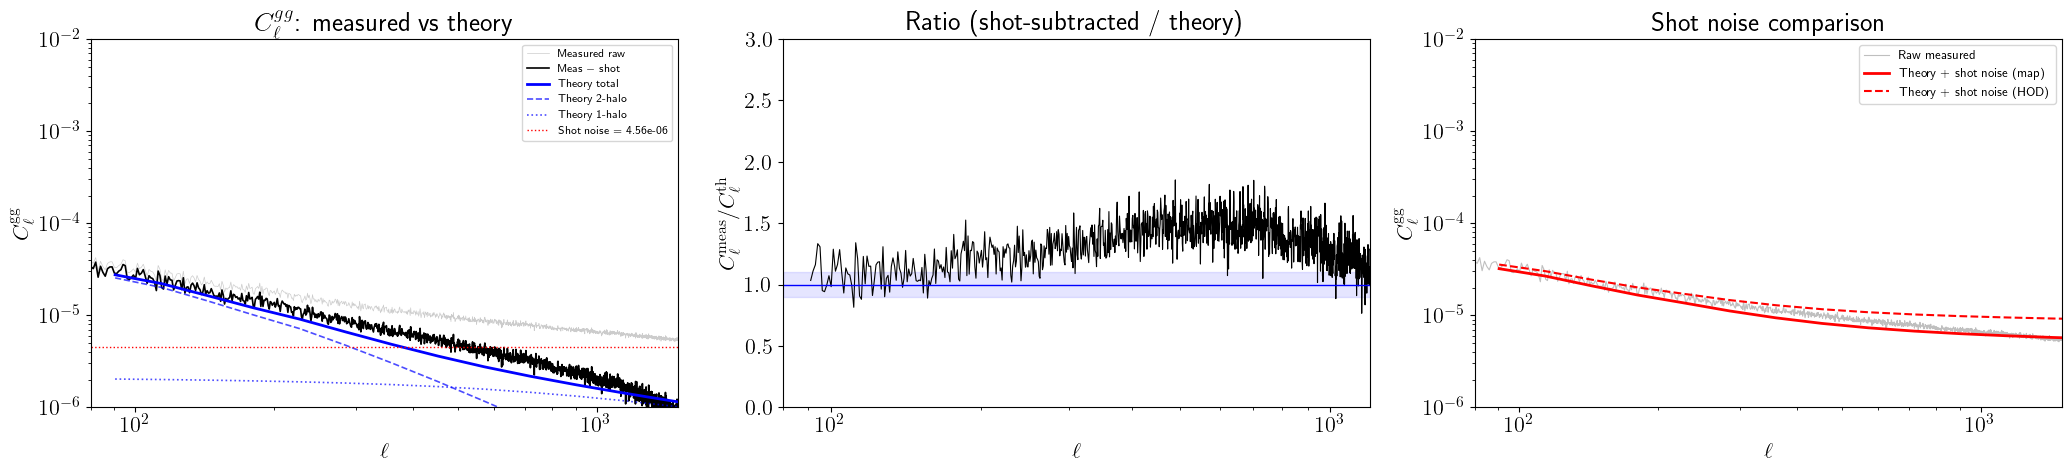

In [6]:
# ============================================================
# Compare measured vs model C_ell^{gg}
# — shot noise, 1-halo/2-halo decomposition, ratio panels
# ============================================================
delta_gal = map_gal / np.mean(map_gal)
Cl_gg_raw = hp.anafast(delta_gal)
ell = np.arange(len(Cl_gg_raw))

# Deconvolve pixel window
Cl_gg_deconv = Cl_gg_raw

# Shot noise from galaxy surface density
Cl_shot, n_gal, nbar_sr = compute_shot_noise_Cl(mock_gals, nside, gal_zmin, gal_zmax)
Cl_gg_no_shot = Cl_gg_deconv - Cl_shot

# HOD-integral shot noise
Cl_shot_hod = compute_hod_shot_noise_Cl(Cls_test)

# Theory total and 1h/2h decomposition
ell_th = np.array(Cls_test.ell_array)
Cl_th = np.array(Cls_test.Cl_gal_gal_tot_mat[:, 0, 0])
cl_decomp = compute_Cl_gg_1h_2h(Cls_test)

from scipy.interpolate import interp1d

# --- Figure: 3 panels ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 5))

# Panel 1: spectra (raw, shot-subtracted, theory, 1h/2h)
ax1.plot(ell, Cl_gg_deconv, 'gray', alpha=0.4, lw=0.5, label='Measured raw')
ax1.plot(ell, np.maximum(Cl_gg_no_shot, 1e-8), 'k-', lw=1.2, label='Meas $-$ shot')
ax1.plot(ell_th, Cl_th, 'b-', lw=2, label='Theory total')
ax1.plot(cl_decomp['ell'], cl_decomp['Cl_2h'], 'b--', lw=1.2, alpha=0.7, label='Theory 2-halo')
ax1.plot(cl_decomp['ell'], cl_decomp['Cl_1h'], 'b:', lw=1.2, alpha=0.7, label='Theory 1-halo')
ax1.axhline(Cl_shot, color='r', ls=':', lw=1, label=f'Shot noise = {Cl_shot:.2e}')
ax1.set(xscale='log', yscale='log', xlabel=r'$\ell$', ylabel=r'$C_\ell^{\mathrm{gg}}$',
        xlim=(80, 1500), ylim=(1e-6, 1e-2))
ax1.legend(fontsize=8)
ax1.set_title(r'$C_\ell^{gg}$: measured vs theory')

# Panel 2: ratio (shot-subtracted / theory)
Cl_th_at_ell = interp1d(ell_th, Cl_th, bounds_error=False, fill_value=np.nan)(ell)
ratio = np.where(Cl_th_at_ell > 0, Cl_gg_no_shot / Cl_th_at_ell, np.nan)
mask_ratio = (ell >= 80) & (ell <= 1200) & (Cl_gg_no_shot > 0)
ax2.plot(ell[mask_ratio], ratio[mask_ratio], 'k-', lw=0.8)
ax2.axhline(1.0, color='b', ls='-', lw=1)
ax2.axhspan(0.9, 1.1, alpha=0.1, color='blue')
ax2.set(xscale='log', xlabel=r'$\ell$', ylabel=r'$C_\ell^{\mathrm{meas}} / C_\ell^{\mathrm{th}}$',
        xlim=(80, 1200), ylim=(0.0, 3.0))
ax2.set_title('Ratio (shot-subtracted / theory)')

# Panel 3: three spectra comparison (raw, minus shot, theory+shot)
ax3.plot(ell, Cl_gg_deconv, 'gray', alpha=0.5, lw=0.8, label='Raw measured')
ax3.plot(ell_th, Cl_th + Cl_shot, 'r-', lw=2, label='Theory + shot noise (map)')
ax3.plot(ell_th, Cl_th + Cl_shot_hod, 'r--', lw=1.5, label='Theory + shot noise (HOD)')
ax3.set(xscale='log', yscale='log', xlabel=r'$\ell$', ylabel=r'$C_\ell^{\mathrm{gg}}$',
        xlim=(80, 1500), ylim=(1e-6, 1e-2))
ax3.legend(fontsize=9)
ax3.set_title('Shot noise comparison')

plt.tight_layout()

# Band-averaged ratio diagnostics
band_ratios_gg = compute_Cl_ratio_in_bands(
    ell, np.maximum(Cl_gg_no_shot, 1e-20), ell_th, Cl_th)




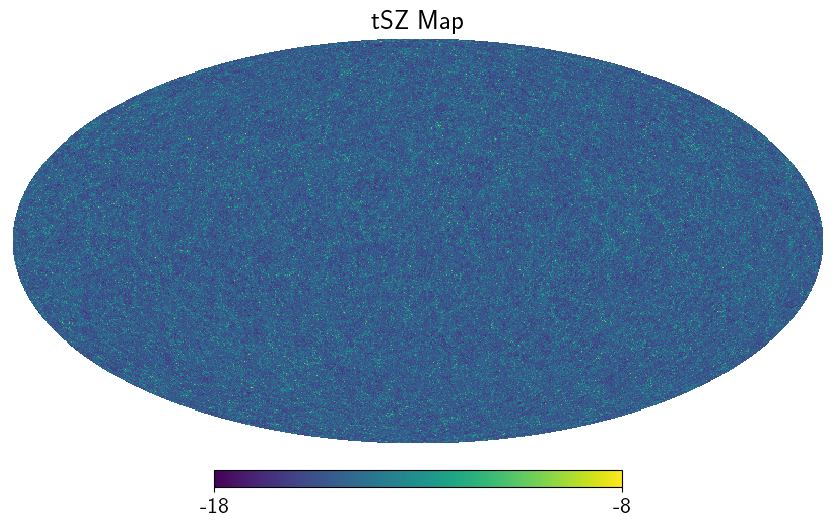

In [16]:
map_tSZ = saved_data["map_ymap"]
hp.mollview(np.log(map_tSZ), title="tSZ Map", min=-18, max=-8)


In [17]:
saved_data.keys()


dict_keys(['mock_gals_all', 'map_rhom', 'map_ymap', 'map_ksz', 'map_tau'])

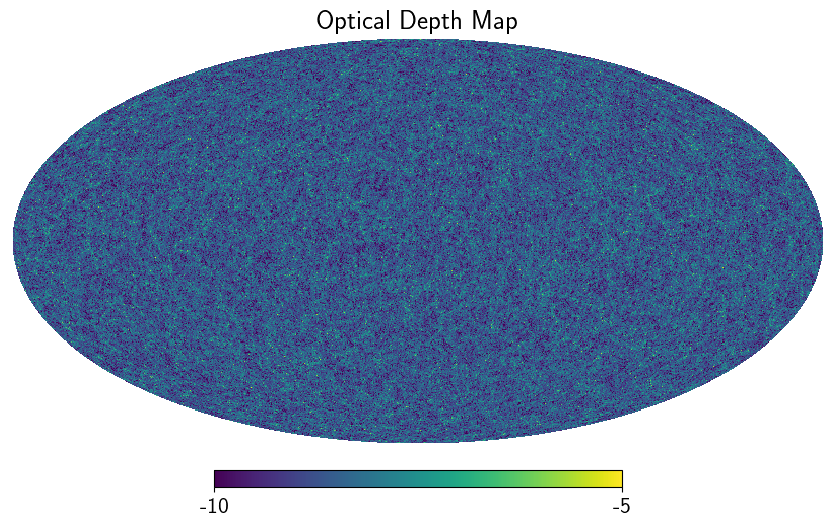

In [ ]:
map_tau = saved_data["map_tau"]
hp.mollview(np.log(map_tau), title="Optical Depth Map", min=-10, max=-5)




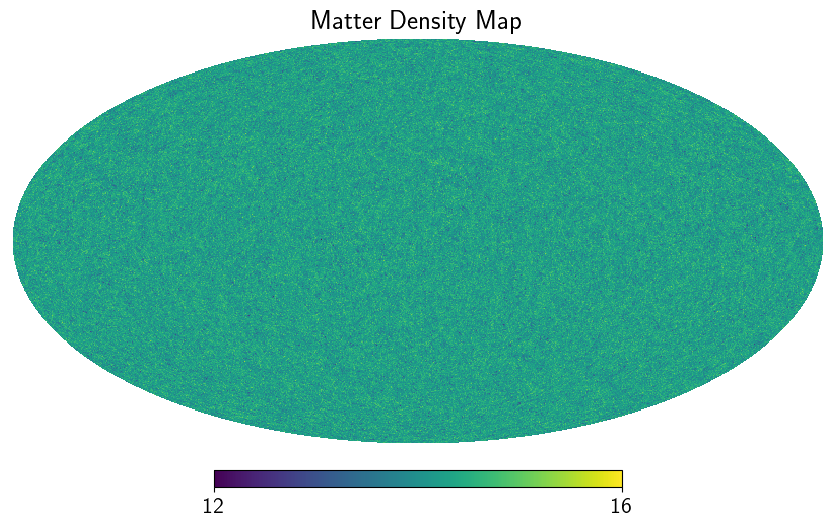

In [38]:
map_rhom = saved_data["map_rhom"]
hp.mollview(np.log10(map_rhom), title=" Matter Density Map", min=12, max=16)




In [39]:
Cl_gy_raw = hp.anafast(delta_gal, map_tSZ)
Cl_gtau_raw = hp.anafast(delta_gal, map_tau)
Cl_gg_raw = hp.anafast(delta_gal)
Cl_gm_raw = hp.anafast(delta_gal, map_rhom)


[None,
 None,
 Text(0.5, 0, '$\\ell$'),
 Text(0, 0.5, '$C_\\ell^{\\mathrm{gm}}$'),
 (100, 1024),
 (100000000.0, 10000000000.0)]

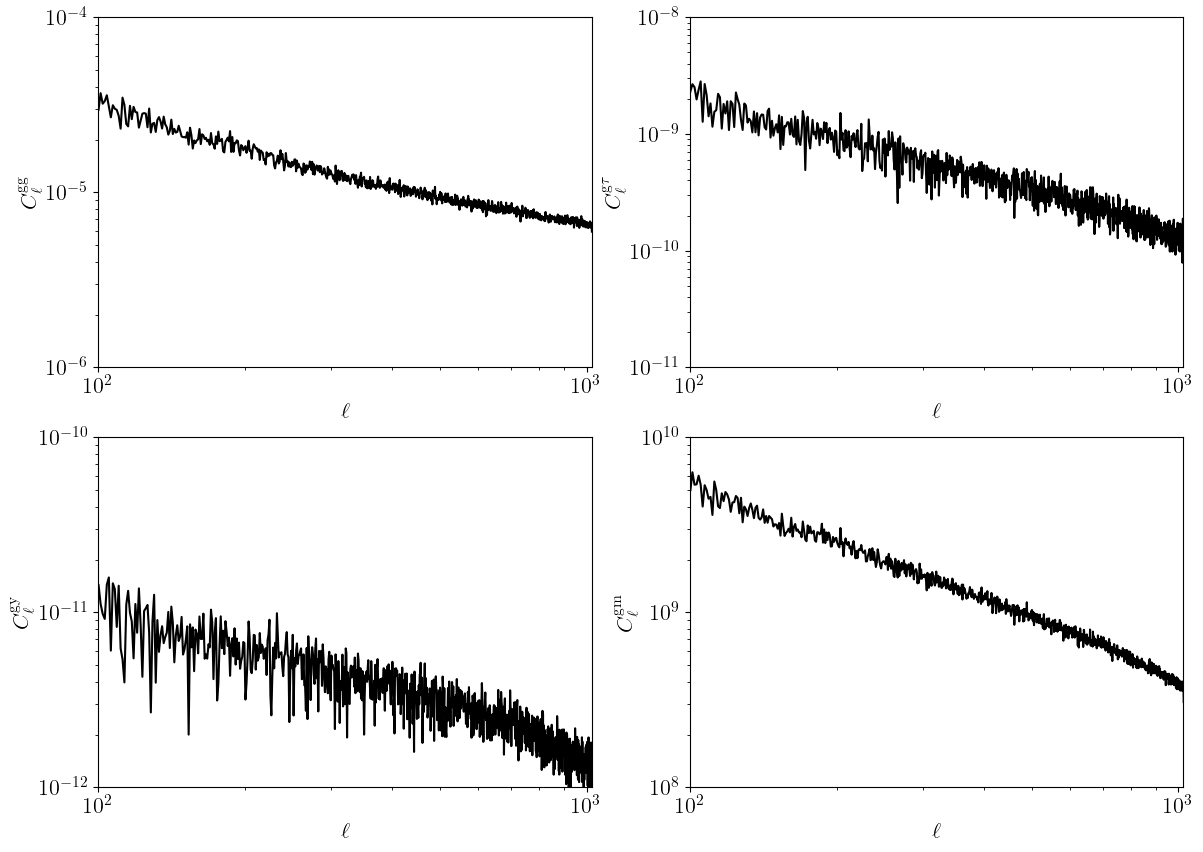

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(ell, Cl_gg_raw, 'k-')
axes[0,0].set(xscale='log', yscale='log', xlabel=r'$\ell$', ylabel=r'$C_\ell^{\mathrm{gg}}$', xlim=(100, 1024), ylim=(1e-6, 1e-4))

# axes[0,0].grid()
axes[0,1].plot(ell, Cl_gtau_raw, 'k-')
axes[0,1].set(xscale='log', yscale='log', xlabel=r'$\ell$', ylabel=r'$C_\ell^{\mathrm{g\tau}}$', xlim=(100, 1024), ylim=(1e-11, 1e-8))

axes[1,0].plot(ell, Cl_gy_raw, 'k-')
axes[1,0].set(xscale='log', yscale='log', xlabel=r'$\ell$', ylabel=r'$C_\ell^{\mathrm{gy}}$', xlim=(100, 1024), ylim=(1e-12, 1e-10))

# axes[0,1].grid()
# axes[1,0].grid()
axes[1,1].plot(ell, Cl_gm_raw, 'k-')
axes[1,1].set(xscale='log', yscale='log', xlabel=r'$\ell$', ylabel=r'$C_\ell^{\mathrm{gm}}$', xlim=(100, 1024), ylim=(1e8, 1e10))
# axes[1,1].grid()




[Cl ratio diagnostics]
  ell [ 100,  300]: <Cl_meas/Cl_th> = 4.867
  ell [ 300,  700]: <Cl_meas/Cl_th> = 6.511
  ell [ 700, 1200]: <Cl_meas/Cl_th> = 6.787


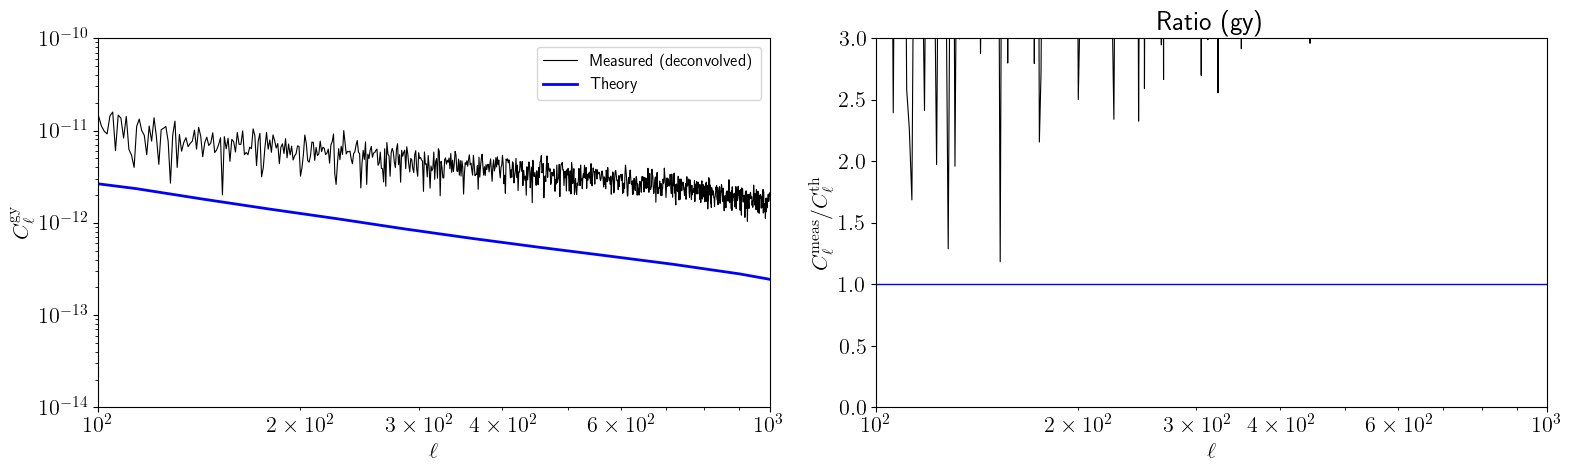

In [12]:
# Compare measured vs model C_ell^{gy} — with ratio panel
map_tSZ = saved_data["map_ymap"]
Cl_gy_raw = hp.anafast(delta_gal, map_tSZ)

pixwin = hp.pixwin(nside)[:len(Cl_gy_raw)]
Cl_gy_deconv = Cl_gy_raw / np.where(pixwin > 0, pixwin, 1.0)

ell_th_gy = np.array(Cls_test.ell_array)
Cl_th_gy = np.array(Cls_test.Cl_gal_y_tot_mat[:, 0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(ell, Cl_gy_deconv, 'k-', lw=0.8, label='Measured (deconvolved)')
ax1.plot(ell_th_gy, Cl_th_gy, 'b-', lw=2, label='Theory')
ax1.set(xscale='log', yscale='log', xlabel=r'$\ell$', ylabel=r'$C_\ell^{\mathrm{gy}}$',
        xlim=(100, 1000), ylim=(1e-14, 1e-10))
ax1.legend(fontsize=12)

Cl_th_gy_at_ell = interp1d(ell_th_gy, Cl_th_gy, bounds_error=False, fill_value=np.nan)(ell)
mask_gy = (ell >= 80) & (ell <= 1000) & (Cl_gy_deconv > 0) & np.isfinite(Cl_th_gy_at_ell) & (Cl_th_gy_at_ell > 0)
ratio_gy = Cl_gy_deconv / np.where(Cl_th_gy_at_ell > 0, Cl_th_gy_at_ell, np.nan)
ax2.plot(ell[mask_gy], ratio_gy[mask_gy], 'k-', lw=0.8)
ax2.axhline(1.0, color='b', ls='-', lw=1)
ax2.set(xscale='log', xlabel=r'$\ell$', ylabel=r'$C_\ell^{\mathrm{meas}} / C_\ell^{\mathrm{th}}$',
        xlim=(100, 1000), ylim=(0, 3))
ax2.set_title('Ratio (gy)')
plt.tight_layout()

_ = compute_Cl_ratio_in_bands(ell, np.maximum(Cl_gy_deconv, 1e-20), ell_th_gy, Cl_th_gy)




Text(0, 0.5, '$\\bar{n}$ [(Mpc/h)$^{-3}$]')

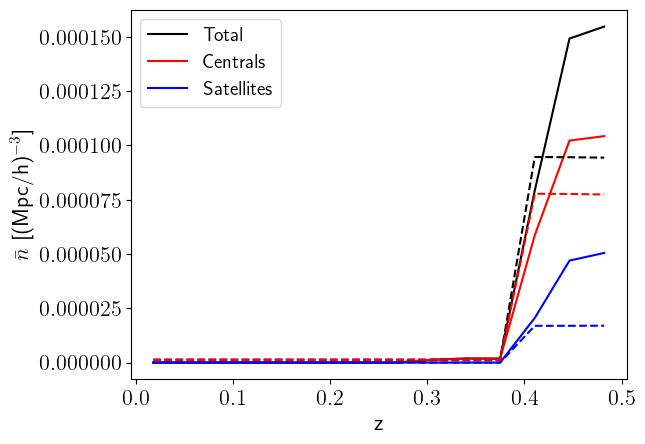

In [13]:
# Galaxy number density vs redshift
gal_z_all = mock_gals[:, 2]
is_cen_all = mock_gals[:, 4]

ndens = compute_ngal_vs_z(gal_z_all, is_cen_all, Prof_test, Cls_test)

plt.figure()
plt.plot(ndens["zcen"], ndens["ngal"], "k-", label="Total")
plt.plot(ndens["zcen"], ndens["ncen"], "r-", label="Centrals")
plt.plot(ndens["zcen"], ndens["nsat"], "b-", label="Satellites")
plt.plot(ndens["zcen"], ndens["ngal_th"], "k--")
plt.plot(ndens["zcen"], ndens["ncen_th"], "r--")
plt.plot(ndens["zcen"], ndens["nsat_th"], "b--")
plt.legend()
plt.xlabel("z"); plt.ylabel(r"$\bar{n}$ [(Mpc/h)$^{-3}$]")


--- HOD Consistency Diagnostics ---
  Ncen: max frac mismatch = 5.313, mean = 0.580 (over 40 populated bins)
  Nsat: max frac mismatch = 15.925, mean = 1.144 (over 32 populated bins)
-----------------------------------


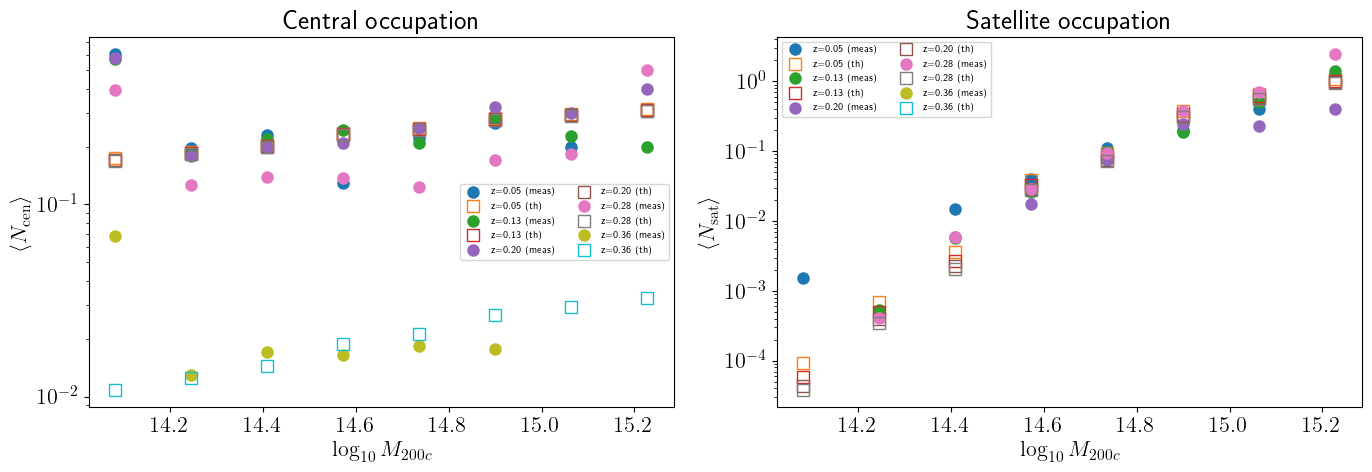

In [112]:
# ============================================================
# HOD Consistency: measured Ncen/Nsat vs theory
# ============================================================
hod_diag = measure_hod_from_catalog(mock_gals, M200c_all, z_all, Cls_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for iz in range(len(hod_diag['z_cen'])):
    lbl = f"z={hod_diag['z_cen'][iz]:.2f}"
    valid = np.isfinite(hod_diag['Ncen_meas'][iz])
    if valid.any():
        axes[0].plot(hod_diag['logM_cen'][valid], hod_diag['Ncen_meas'][iz, valid],
                     'o', ms=8, label=lbl + ' (meas)')
        axes[0].plot(hod_diag['logM_cen'][valid], hod_diag['Ncen_th'][iz, valid],
                     's', ms=8, mfc='none', label=lbl + ' (th)')

    valid_s = np.isfinite(hod_diag['Nsat_meas'][iz])
    if valid_s.any():
        axes[1].plot(hod_diag['logM_cen'][valid_s], hod_diag['Nsat_meas'][iz, valid_s],
                     'o', ms=8, label=lbl + ' (meas)')
        axes[1].plot(hod_diag['logM_cen'][valid_s], hod_diag['Nsat_th'][iz, valid_s],
                     's', ms=8, mfc='none', label=lbl + ' (th)')

axes[0].set(xlabel=r'$\log_{10} M_{200c}$', ylabel=r'$\langle N_{\mathrm{cen}} \rangle$',
            title='Central occupation', yscale='log')
axes[0].legend(fontsize=7, ncol=2)
axes[1].set(xlabel=r'$\log_{10} M_{200c}$', ylabel=r'$\langle N_{\mathrm{sat}} \rangle$',
            title='Satellite occupation', yscale='log')
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()




[HMF comparison — ABSOLUTE] max frac mismatch = 1.000, mean = 1.000 (over 53 bins with >5 halos)

[HMF comparison — renorm]   max frac mismatch = 1.000, mean = 1.000


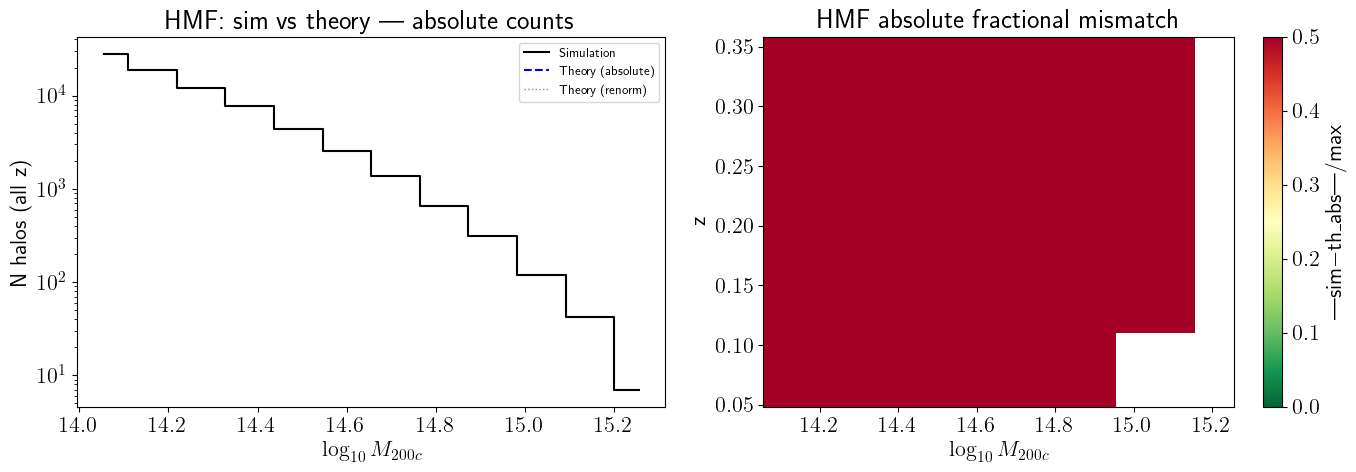

In [122]:
# ============================================================
# HMF: simulation halo catalog vs theory mass function
# — Primary comparison uses ABSOLUTE theory counts (no rescaling)
# ============================================================
hmf_diag = compare_sim_vs_theory_hmf(M200c_all, z_all, Cls_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram comparison in mass bins (summed over z) — absolute theory counts
sim_M = hmf_diag['sim_counts'].sum(axis=0)
th_M_abs = hmf_diag['theory_counts_abs'].sum(axis=0)
th_M_norm = hmf_diag['theory_counts_norm'].sum(axis=0)
axes[0].step(hmf_diag['logM_cen'], sim_M, where='mid', color='k', lw=1.5, label='Simulation')
axes[0].step(hmf_diag['logM_cen'], th_M_abs, where='mid', color='b', lw=1.5, ls='--', label='Theory (absolute)')
axes[0].step(hmf_diag['logM_cen'], th_M_norm, where='mid', color='b', lw=1.0, ls=':', alpha=0.5, label='Theory (renorm)')
axes[0].set(xlabel=r'$\log_{10} M_{200c}$', ylabel='N halos (all z)',
            title='HMF: sim vs theory — absolute counts', yscale='log')
axes[0].legend(fontsize=9)

# Right: absolute fractional mismatch heatmap (NOT renormalized)
fm = hmf_diag['frac_mismatch_abs']
im = axes[1].imshow(fm, origin='lower', aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=0.5,
                    extent=[hmf_diag['logM_cen'][0], hmf_diag['logM_cen'][-1],
                            hmf_diag['z_cen'][0], hmf_diag['z_cen'][-1]])
axes[1].set(xlabel=r'$\log_{10} M_{200c}$', ylabel='z',
            title='HMF absolute fractional mismatch')
plt.colorbar(im, ax=axes[1], label=r"|sim$-$th_abs|/max")
plt.tight_layout()

In [ ]:
# ============================================================
# Mthresh / nbar diagnostic: solver health check
# ============================================================
# Mthresh solver in get_radial_profiles.get_Mthresh uses:
#   Mthresh_array = jnp.logspace(9, 14, 2*npoints)
# So the search boundaries are log10(M) = 9.0 and 14.0.
MTHRESH_LOG10_LO = 9.0
MTHRESH_LOG10_HI = 14.0
BOUNDARY_MARGIN_DEX = 0.15  # flag if within 0.15 dex of either boundary

# --- Mthresh array summary ---
Mthresh_arr = np.array(Cls_test.Mthresh_array)
log10_Mthresh = np.log10(Mthresh_arr)
z_theory = np.array(Cls_test.z_array)

print("=" * 65)
print("  Mthresh / nbar DIAGNOSTIC")
print("=" * 65)
print(f"\nMthresh_array (log10 units), {len(log10_Mthresh)} z-bins:")
print(f"  min = {log10_Mthresh.min():.4f},  median = {np.median(log10_Mthresh):.4f},  max = {log10_Mthresh.max():.4f}")
print(f"  full array: {np.array2string(log10_Mthresh, precision=3, separator=', ')}")

# --- nbar target vs realized comparison ---
# Interpolate the target nbar(z) from analysis_dict onto the theory z grid
nbar_target_on_zgrid = np.interp(
    z_theory,
    analysis_dict["nbar_gal_comoving_zarray"],
    analysis_dict["nbar_gal_comoving_val"],
)
nbar_realized = np.array(Cls_test.nbarz)

print(f"\n{'z':>6s}  {'log10Mth':>9s}  {'nbar_target':>12s}  {'nbar_realized':>14s}  {'frac_diff':>10s}")
print("-" * 58)
frac_diffs = []
for i in range(len(z_theory)):
    nt = nbar_target_on_zgrid[i]
    nr = nbar_realized[i]
    denom = max(abs(nt), abs(nr), 1e-30)
    fd = abs(nt - nr) / denom if denom > 1e-30 else 0.0
    frac_diffs.append(fd)
    print(f"{z_theory[i]:6.3f}  {log10_Mthresh[i]:9.3f}  {nt:12.4e}  {nr:14.4e}  {fd:10.4f}")

frac_diffs = np.array(frac_diffs)
# Only report stats where target nbar > 0 (inside the galaxy z-window)
active = nbar_target_on_zgrid > 1e-15
if active.any():
    print(f"\nFractional mismatch (active z-bins only, nbar_target > 0):")
    print(f"  max  = {frac_diffs[active].max():.4e}")
    print(f"  mean = {frac_diffs[active].mean():.4e}")
    print(f"  med  = {np.median(frac_diffs[active]):.4e}")
else:
    print("\nNo active z-bins (nbar_target is zero everywhere on theory grid).")

# --- Boundary check ---
near_lo = log10_Mthresh < (MTHRESH_LOG10_LO + BOUNDARY_MARGIN_DEX)
near_hi = log10_Mthresh > (MTHRESH_LOG10_HI - BOUNDARY_MARGIN_DEX)
boundary_limited = near_lo | near_hi

print(f"\nBoundary check (solver range: log10M = [{MTHRESH_LOG10_LO}, {MTHRESH_LOG10_HI}], margin = {BOUNDARY_MARGIN_DEX} dex):")
if boundary_limited.any():
    print(f"  WARNING: {boundary_limited.sum()} z-bin(s) appear boundary-limited:")
    for i in np.where(boundary_limited)[0]:
        side = "LOW" if near_lo[i] else "HIGH"
        print(f"    z = {z_theory[i]:.3f}, log10(Mthresh) = {log10_Mthresh[i]:.3f}  [{side} boundary]")
else:
    print("  OK — no z-bins near solver boundaries.")
print("=" * 65)

L1 mismatch (integrated |nz_mock - nz_analytic|): 1.6140
Max fractional difference: 1.0000
[nz consistency] max fractional mismatch = 0.0000e+00, mean = 0.0000e+00  (rtol=0.05)


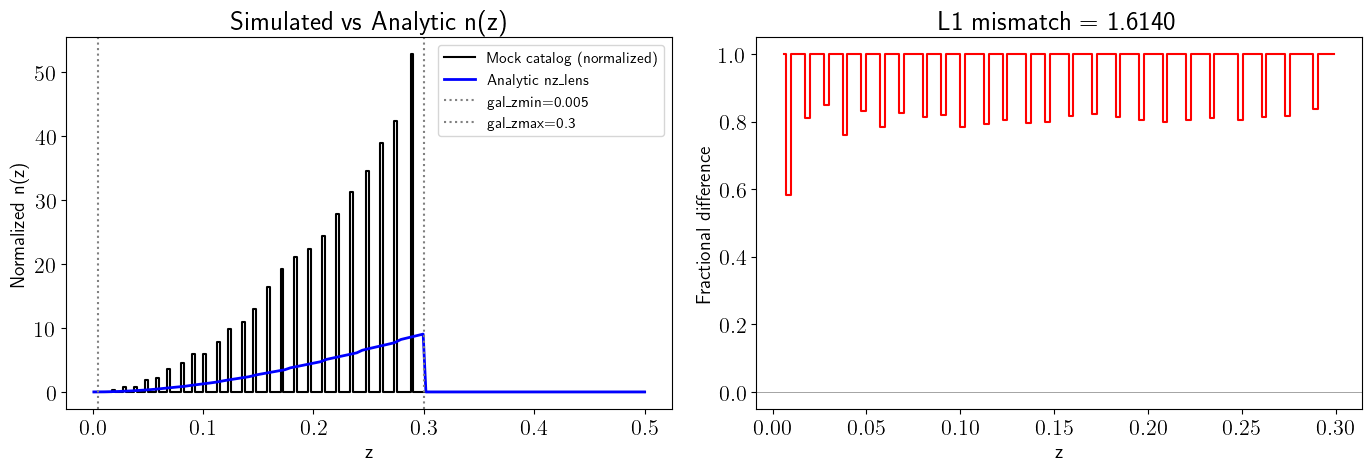

In [121]:
# ============================================================
# n(z) consistency validation: simulated vs analytic nz_lens
# ============================================================
# Use the same z-range from build_config everywhere
dz = zarray_lens[1] - zarray_lens[0]
bin_edges = np.concatenate([
    [zarray_lens[0] - dz/2],
    0.5*(zarray_lens[1:] + zarray_lens[:-1]),
    [zarray_lens[-1] + dz/2],
])

# Histogram of mock galaxy redshifts
sel_z = (gal_z_all >= gal_zmin) & (gal_z_all <= gal_zmax)
counts, _ = np.histogram(gal_z_all[sel_z], bins=bin_edges)
nz_mock_raw = counts.astype(float)
nz_mock_norm = nz_mock_raw / np.trapz(nz_mock_raw, zarray_lens) if nz_mock_raw.sum() > 0 else nz_mock_raw

# Analytic nz_lens from build_config
nz_analytic = nz_lens[0]

# --- Overlay plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.step(zarray_lens, nz_mock_norm, where='mid', color='k', lw=1.5, label='Mock catalog (normalized)')
ax1.plot(zarray_lens, nz_analytic, 'b-', lw=2, label='Analytic nz\_lens')
ax1.axvline(gal_zmin, ls=':', color='gray', label=f'gal\_zmin={gal_zmin}')
ax1.axvline(gal_zmax, ls=':', color='gray', label=f'gal\_zmax={gal_zmax}')
ax1.set_xlabel('z', fontsize=14)
ax1.set_ylabel('Normalized n(z)', fontsize=14)
ax1.set_title('Simulated vs Analytic n(z)')
ax1.legend(fontsize=11)

# --- Scalar mismatch metric ---
mask = (nz_analytic > 1e-10) | (nz_mock_norm > 1e-10)
if mask.any():
    residual = np.abs(nz_mock_norm[mask] - nz_analytic[mask])
    L1 = np.trapz(residual, zarray_lens[mask])
    denom = np.maximum(nz_analytic[mask], nz_mock_norm[mask])
    frac_diff = residual / np.where(denom > 0, denom, 1.0)

    ax2.step(zarray_lens[mask], frac_diff, where='mid', color='r', lw=1.5)
    ax2.set_xlabel('z', fontsize=14)
    ax2.set_ylabel('Fractional difference', fontsize=14)
    ax2.set_title(f'L1 mismatch = {L1:.4f}')
    ax2.axhline(0, ls='-', color='gray', lw=0.5)

plt.tight_layout()

print(f"L1 mismatch (integrated |nz_mock - nz_analytic|): {L1:.4f}")
print(f"Max fractional difference: {frac_diff.max():.4f}")

# Also run the built-in consistency check on the stored config
nbar_stored = analysis_dict['nbar_gal_comoving_val']
nz_stored = analysis_dict['nz_lens_info_dict']['nz0']
_ = check_nz_nbar_consistency(nbar_stored, nz_stored, zarray_lens, cosmo_jax)




In [13]:
# ============================================================
# Diagnostic summary table
# ============================================================
# Collect n(z) mismatch from cell 11
nz_mismatch_val = L1 if "L1" in dir() else 0.0

# Cl_gy band ratios
band_ratios_gy = compute_Cl_ratio_in_bands(
    ell, np.maximum(Cl_gy_deconv, 1e-20), ell_th_gy, Cl_th_gy)

print_diagnostic_summary(
    nz_mismatch=nz_mismatch_val,
    hod_diag=hod_diag,
    Cl_shot=Cl_shot,
    Cl_shot_hod=Cl_shot_hod,
    band_ratios_gg=band_ratios_gg,
    band_ratios_gy=band_ratios_gy,
    hmf_diag=hmf_diag,
)


[Cl ratio diagnostics]
  ell [ 100,  300]: <Cl_meas/Cl_th> = 0.875
  ell [ 300,  700]: <Cl_meas/Cl_th> = 0.896
  ell [ 700, 1200]: <Cl_meas/Cl_th> = 0.897

  DIAGNOSTIC SUMMARY
  n(z) L1 mismatch           : 0.2974
  HOD Ncen max/mean mismatch : 1.447 / 0.260
  HOD Nsat max/mean mismatch : 0.606 / 0.162
  HMF max/mean mismatch      : 1.000 / 0.547
  Shot noise (map-level)     : 5.9986e-05
  Shot noise (HOD integral)  : 5.1948e-05
  --- Cl_gg bandpower ratios (meas/th) ---
    ell [ 100,  300]: 1.516  [HIGH]
    ell [ 300,  700]: 1.029  [OK]
    ell [ 700, 1200]: 0.748  [LOW]
  --- Cl_gy bandpower ratios (meas/th) ---
    ell [ 100,  300]: 0.875  [OK]
    ell [ 300,  700]: 0.896  [OK]
    ell [ 700, 1200]: 0.897  [OK]



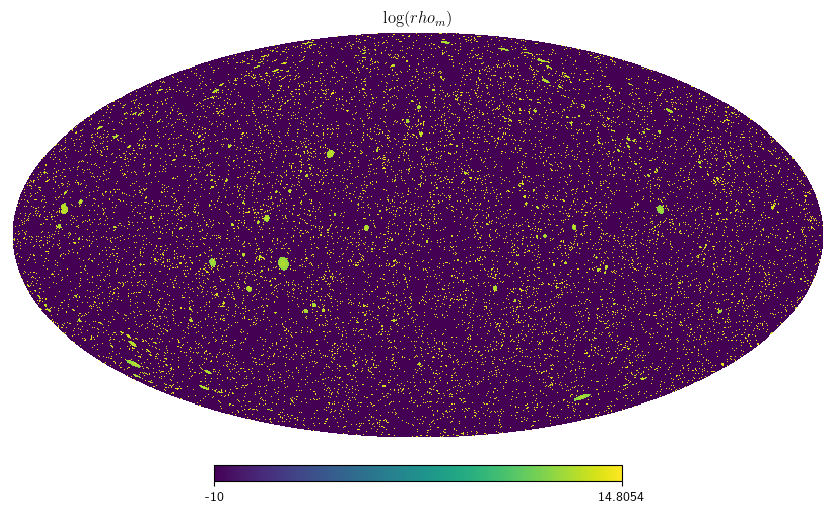

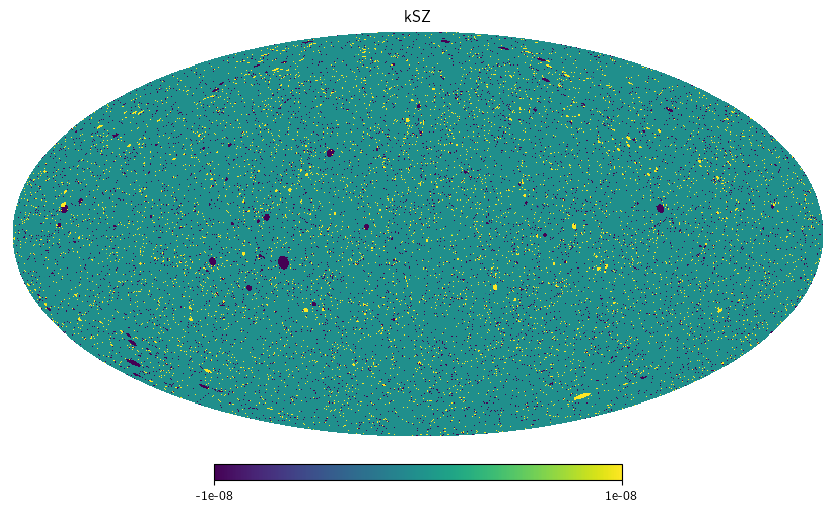

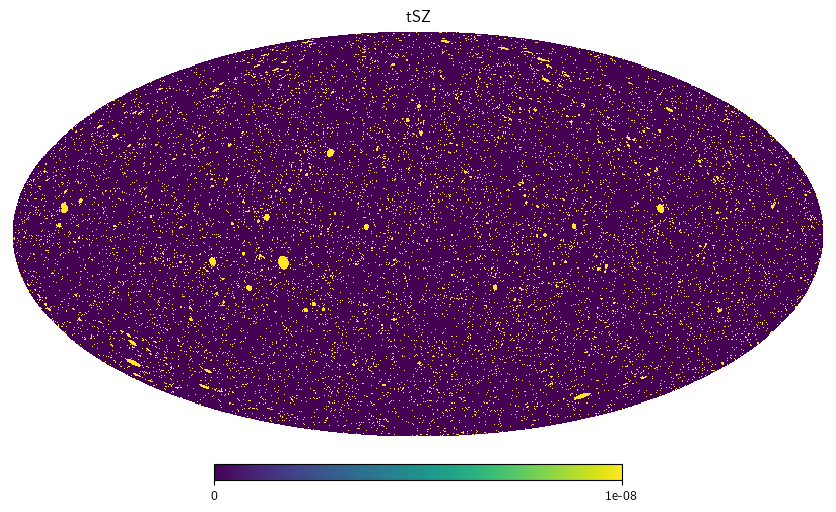

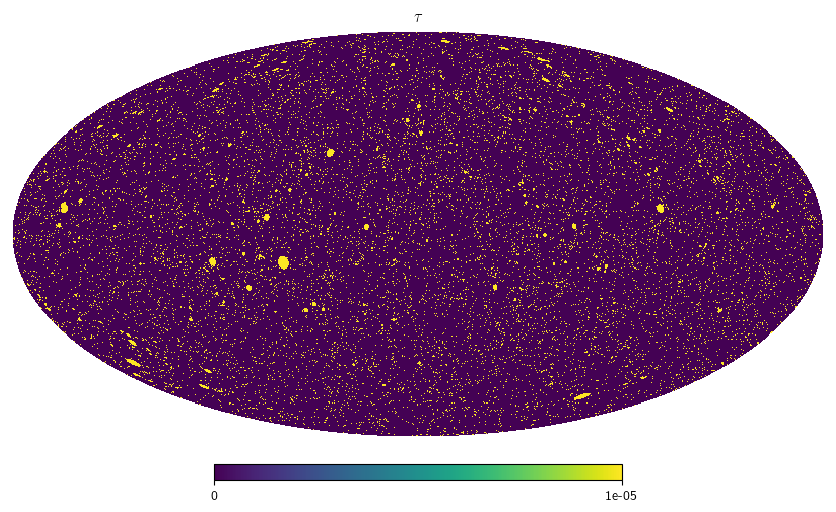

In [14]:
# Mollweide map views
map_rhom = saved_data["map_rhom"]
map_ksz = saved_data["map_ksz"]
map_ymap = saved_data["map_ymap"]
map_tau = saved_data["map_tau"]

hp.mollview(np.log10(map_rhom + 1e-10), title=r"$\log(rho_m)$")
hp.mollview(map_ksz, title="kSZ", min=-1e-8, max=1e-8)
hp.mollview(map_ymap, title="tSZ", min=0, max=1e-8)
hp.mollview(map_tau, title=r"$\tau$", min=0, max=1e-5)


Most massive halo: ra=257.96, dec=6.25, z=0.2755, M200c=2.041e+15


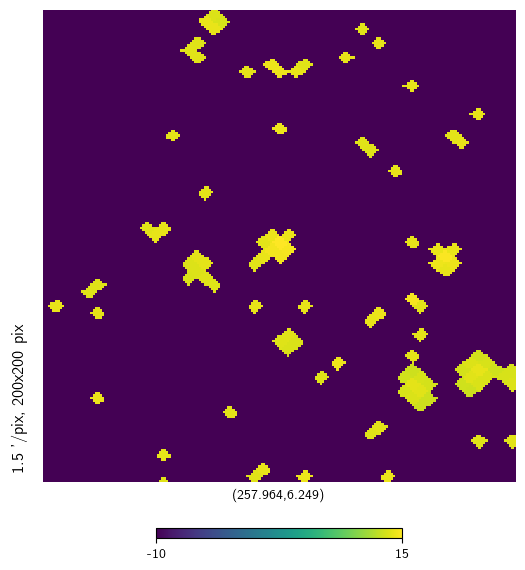

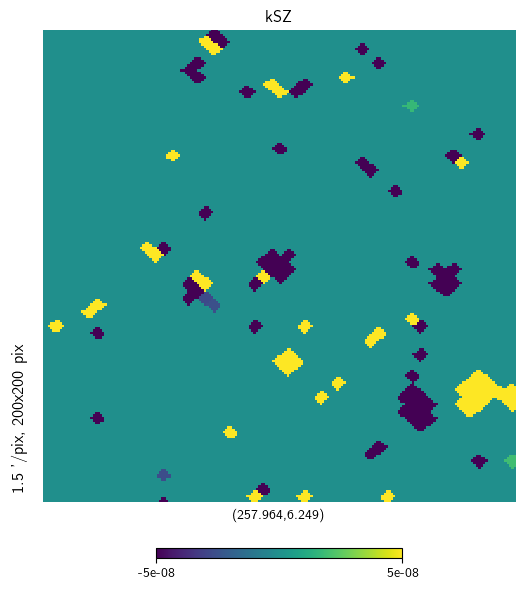

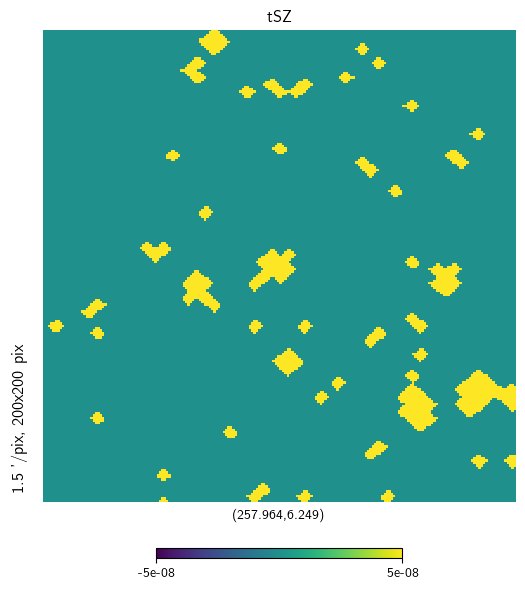

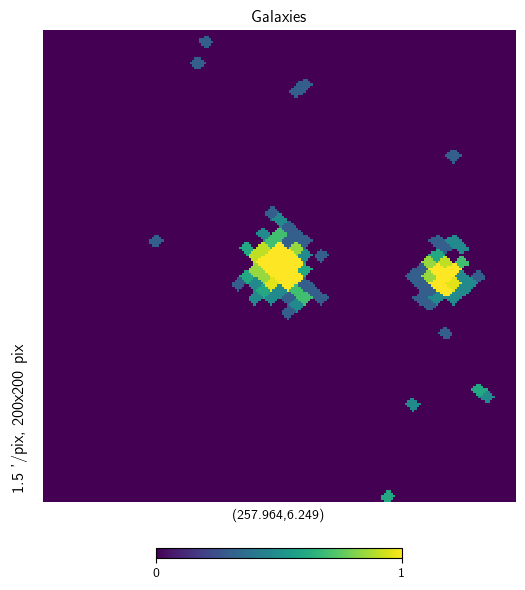

In [15]:
# Gnomonic views around the most massive halo
ind_maxM = np.argmax(M200c_all)
rot = (ra_all[ind_maxM], dec_all[ind_maxM])
print(f"Most massive halo: ra={rot[0]:.2f}, dec={rot[1]:.2f}, z={z_all[ind_maxM]:.4f}, M200c={M200c_all[ind_maxM]:.3e}")

hp.gnomview(np.log10(map_rhom + 1e-10), title="", rot=rot)
hp.gnomview(map_ksz, title="kSZ", min=-5e-8, max=5e-8, rot=rot)
hp.gnomview(map_ymap, title="tSZ", min=-5e-8, max=5e-8, rot=rot)
hp.gnomview(np.log10(map_gal + 1e-10), title="Galaxies", rot=rot, min=0, max=np.log10(10))

Text(0, 0.5, 'DEC')

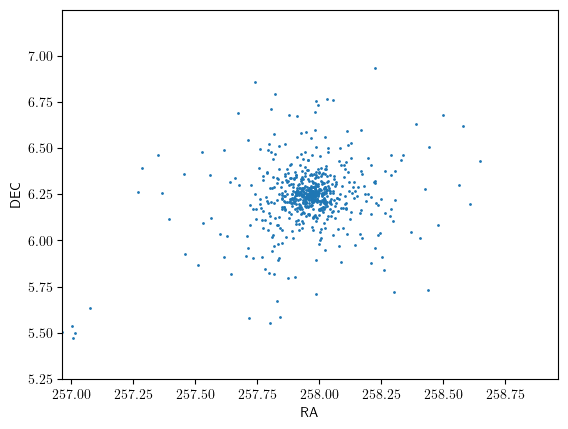

In [16]:
# Scatter of galaxies near most massive halo
gal_ra_all = mock_gals[:, 0]
gal_dec_all = mock_gals[:, 1]

plt.figure()
plt.scatter(gal_ra_all, gal_dec_all, s=1)
plt.xlim(rot[0] - 1, rot[0] + 1)
plt.ylim(rot[1] - 1, rot[1] + 1)
plt.xlabel("RA"); plt.ylabel("DEC")
